# From Post To Personality (P2P): MBTI Prediction from Social Media

**Paper:** Ma et al., *From Post To Personality: Harnessing LLMs for MBTI Prediction in Social Media*, CIKM 2025

This notebook demonstrates the P2P pipeline and evaluates its performance:

1. **Setup and Data Loading** — Load preprocessed dataset and artifacts
2. **Dataset Overview** — PersonalityCafe statistics and class distribution
3. **Live P2P Pipeline Demo** — Run FAISS retrieval + DeepSeek-V3 API prediction on sample users
4. **P2P Results** — Per-dimension Accuracy, F1, AUC compared to paper
5. **Baseline Comparison** — P2P vs Naive Bayes, Logistic Regression, SVM, XGBoost
6. **Confusion Matrices** — Per-dimension and full 16-way
7. **Prediction Distribution Analysis** — True vs predicted distribution and error patterns

---
## 1. Setup and Data Loading

In [1]:
import os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42

ARTIFACTS = Path('../artifacts')
SPLIT_PARQUET       = ARTIFACTS / 'split.parquet'
PREDICTIONS_PARQUET = ARTIFACTS / 'predictions.parquet'

for f in [SPLIT_PARQUET, PREDICTIONS_PARQUET]:
    print(f'  {f.name:30s} {"found" if f.exists() else "MISSING"}')

VALID_TYPES = {'INFP','INFJ','INTP','INTJ','ENFP','ENFJ','ENTP','ENTJ',
               'ISFP','ISFJ','ISTP','ISTJ','ESFP','ESFJ','ESTP','ESTJ'}

  split.parquet                  found
  predictions.parquet            found


---
## 2. Dataset Overview

In [2]:
df_all = pd.read_parquet(SPLIT_PARQUET)
df_train = df_all[df_all['split'] == 'train'].reset_index(drop=True)
df_test  = df_all[df_all['split'] == 'test'].reset_index(drop=True)

print(f'Total users:  {len(df_all)}')
print(f'Train:        {len(df_train)} (60%)')
print(f'Validation:   {len(df_all[df_all["split"]=="val"])} (20%)')
print(f'Test:         {len(df_test)} (20%)')
print(f'MBTI types:   {df_all["type"].nunique()}')
print(f'Imbalance:    {df_train["type"].value_counts().max()} (INFP) / '
      f'{df_train["type"].value_counts().min()} (ESTJ) = '
      f'{df_train["type"].value_counts().max() / df_train["type"].value_counts().min():.0f}x')

Total users:  8675
Train:        5205 (60%)
Validation:   1735 (20%)
Test:         1735 (20%)
MBTI types:   16
Imbalance:    1099 (INFP) / 23 (ESTJ) = 48x


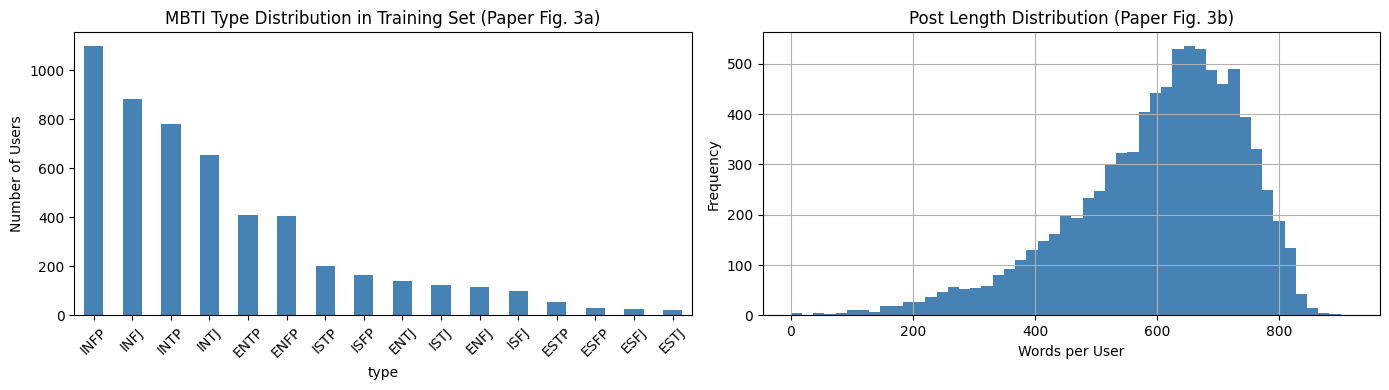

In [3]:
counts = df_train['type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MBTI Type Distribution in Training Set (Paper Fig. 3a)')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=45)

df_all['len_clean'].clip(upper=3000).hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Post Length Distribution (Paper Fig. 3b)')
axes[1].set_xlabel('Words per User')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## 3. Live P2P Pipeline Demo

Run the full P2P pipeline on test users: load cached features and FAISS index, retrieve k=5 similar users, call DeepSeek-V3 API for MBTI prediction.

In [4]:
# 3.1 Load artifacts
import faiss
from dotenv import load_dotenv

FEATURES_PARQUET    = ARTIFACTS / 'features_h.parquet'
FAISS_INDEX_PATH    = ARTIFACTS / 'faiss.index'
FAISS_META_PATH     = ARTIFACTS / 'faiss_meta.parquet'
PREDICTIONS_PARQUET = ARTIFACTS / 'predictions.parquet'

# Load features, FAISS index, and metadata
df_feat = pd.read_parquet(FEATURES_PARQUET)
index = faiss.read_index(str(FAISS_INDEX_PATH))
df_meta = pd.read_parquet(FAISS_META_PATH)
K = 5

print(f'Features:    {len(df_feat)} users')
print(f'FAISS index: {index.ntotal} vectors, dim={index.d}')
print(f'Metadata:    {len(df_meta)} training users')

Features:    8675 users
FAISS index: 5205 vectors, dim=4864
Metadata:    5205 training users


In [5]:
# 3.2 Setup DeepSeek-V3 API and Sentence-BERT
from openai import OpenAI
from sentence_transformers import SentenceTransformer
import re

load_dotenv(ARTIFACTS.parent / '.env')
api_key = os.environ.get('DEEPSEEK_API_KEY', '')
client = OpenAI(api_key=api_key, base_url='https://api.deepseek.com') if api_key else None

sbert = SentenceTransformer('all-mpnet-base-v2')

# Paper Appendix C prompts
PREDICT_PROMPT = (
    'According to the following content <CONTENT>, combined with the key features <FEATURES> '
    'extracted by the local model, refer to the MBTI distribution of similar texts <SIM-TEXTS>, '
    'and predict the MBTI type from four dimensions (only output four letters). '
    'The emphases of the four dimensions are as follows:\n'
    '1. Social tendency (Extraversion E / Introversion I)\n'
    '2. Information processing mode (Sensing S / iNtuition N)\n'
    '3. Decision-making mode (Thinking T / Feeling F)\n'
    '4. Lifestyle (Judging J / Perceiving P)'
)

SYSTEM_PROMPT = (
    'You are an MBTI personality type classifier. '
    'You MUST respond with ONLY 4 uppercase letters representing the MBTI type. '
    'Valid types: INFP, INFJ, INTP, INTJ, ENFP, ENFJ, ENTP, ENTJ, '
    'ISFP, ISFJ, ISTP, ISTJ, ESFP, ESFJ, ESTP, ESTJ. '
    'No explanation, no other text. Just 4 letters.'
)

def parse_mbti(raw):
    text = raw.strip().upper()
    if text in VALID_TYPES: return text
    match = re.search(r'\b([EI][SN][TF][JP])\b', text)
    if match: return match.group(1)
    match = re.search(r'[EI][SN][TF][JP]', text)
    if match: return match.group(0)
    return 'PARSE_FAIL'

print(f'API:          {"connected" if client else "NOT SET — add DEEPSEEK_API_KEY to .env"}')
print(f'Sentence-BERT: all-mpnet-base-v2 (dim={sbert.get_sentence_embedding_dimension()})')

API:          connected
Sentence-BERT: all-mpnet-base-v2 (dim=768)


In [6]:
# 3.3 Run P2P predictions on ALL test users (parallel API calls)
import asyncio
from openai import AsyncOpenAI

df_test_feat = df_feat[df_feat['split'] == 'test'].reset_index(drop=True)

# Load hidden states for FAISS queries
HS_TEST_PATH = ARTIFACTS / 'hidden_states_test.npy'
if HS_TEST_PATH.exists():
    hs_test = np.load(HS_TEST_PATH)
    sbert_test = sbert.encode(df_test_feat['posts_clean'].tolist(), show_progress_bar=True, batch_size=64).astype('float32')
    faiss.normalize_L2(sbert_test)
    hs_norm = hs_test.copy().astype('float32')
    faiss.normalize_L2(hs_norm)
    test_vectors = np.concatenate([sbert_test, hs_norm], axis=1)
else:
    sbert_test = sbert.encode(df_test_feat['posts_clean'].tolist(), show_progress_bar=True, batch_size=64).astype('float32')
    faiss.normalize_L2(sbert_test)
    padding = np.zeros((len(sbert_test), index.d - sbert_test.shape[1]), dtype='float32')
    test_vectors = np.concatenate([sbert_test, padding], axis=1)

D, I_idx = index.search(test_vectors, K)
print(f'FAISS: retrieved top-{K} neighbors for {len(df_test_feat)} test users')

# Parallel prediction
MAX_CONCURRENT = 25
async_client = AsyncOpenAI(api_key=api_key, base_url='https://api.deepseek.com')

async def predict_one(posts, features, neighbors_idx, sem):
    async with sem:
        sim_texts = [f"{r+1}. {df_meta.iloc[j]['type']}: '{df_meta.iloc[j]['posts_clean'][:200]}'" for r, j in enumerate(neighbors_idx)]
        prompt = (PREDICT_PROMPT
            .replace('<CONTENT>', posts[:3000])
            .replace('<FEATURES>', features[:500])
            .replace('<SIM-TEXTS>', '\n'.join(sim_texts)))
        for attempt in range(3):
            try:
                r = await async_client.chat.completions.create(
                    model='deepseek-chat',
                    messages=[{'role': 'system', 'content': SYSTEM_PROMPT},
                              {'role': 'user', 'content': prompt}],
                    max_tokens=10, temperature=0)
                return parse_mbti(r.choices[0].message.content)
            except Exception as e:
                if attempt < 2: await asyncio.sleep(2 ** attempt)
                else: return 'ERROR'

import time

if client:
    df_pred = df_test_feat.copy()
    df_pred['pred'] = ''
    todo = df_pred.index.tolist()
    print(f'Predicting {len(todo)} test users ({MAX_CONCURRENT} parallel)...')
    t0 = time.time()
    sem = asyncio.Semaphore(MAX_CONCURRENT)
    for bs in range(0, len(todo), 100):
        batch = todo[bs:bs+100]
        tasks = [predict_one(df_pred.iloc[i]['posts_clean'], df_pred.iloc[i]['features_h'], I_idx[i], sem) for i in batch]
        results_batch = await asyncio.gather(*tasks)
        for i, pred in zip(batch, results_batch):
            df_pred.at[i, 'pred'] = pred
        done = min(bs+100, len(todo))
        elapsed = time.time()-t0
        eta = (len(todo)-done)/(done/elapsed) if done > 0 else 0
        print(f'  {done}/{len(todo)} | {elapsed/60:.1f}min | ETA: {eta/60:.1f}min')
    df_pred.to_parquet(PREDICTIONS_PARQUET, index=False)
    valid_count = df_pred['pred'].isin(VALID_TYPES).sum()
    errors = (df_pred['pred'] == 'ERROR').sum()
    print(f'\nDone: {valid_count} valid | {errors} errors | {(time.time()-t0)/60:.1f}min')
else:
    print('No API key — using cached predictions')

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

FAISS: retrieved top-5 neighbors for 1735 test users
Predicting 1735 test users (25 parallel)...
  100/1735 | 0.1min | ETA: 2.0min
  200/1735 | 0.2min | ETA: 1.7min
  300/1735 | 0.3min | ETA: 1.6min
  400/1735 | 0.4min | ETA: 1.4min
  500/1735 | 0.5min | ETA: 1.3min
  600/1735 | 0.6min | ETA: 1.2min
  700/1735 | 0.7min | ETA: 1.1min
  800/1735 | 0.8min | ETA: 1.0min
  900/1735 | 0.9min | ETA: 0.9min
  1000/1735 | 1.0min | ETA: 0.8min
  1100/1735 | 1.1min | ETA: 0.6min
  1200/1735 | 1.2min | ETA: 0.5min
  1300/1735 | 1.3min | ETA: 0.4min
  1400/1735 | 1.4min | ETA: 0.3min
  1500/1735 | 1.5min | ETA: 0.2min
  1600/1735 | 1.6min | ETA: 0.1min
  1700/1735 | 1.7min | ETA: 0.0min
  1735/1735 | 1.7min | ETA: 0.0min

Done: 1735 valid | 0 errors | 1.7min


In [7]:
# 3.4 Load predictions for evaluation
df_pred = pd.read_parquet(PREDICTIONS_PARQUET)
valid = df_pred[df_pred['pred'].isin(VALID_TYPES)].copy()
print(f'Predictions: {len(valid)} valid / {len(df_pred)} total')

valid['pred_ie'] = (valid['pred'].str[0] == 'I').astype(int)
valid['pred_ns'] = (valid['pred'].str[1] == 'N').astype(int)
valid['pred_tf'] = (valid['pred'].str[2] == 'F').astype(int)
valid['pred_jp'] = (valid['pred'].str[3] == 'P').astype(int)

dims = [('I/E', 'ie', 'pred_ie'), ('N/S', 'ns', 'pred_ns'),
        ('T/F', 'tf', 'pred_tf'), ('J/P', 'jp', 'pred_jp')]

Predictions: 1735 valid / 1735 total


---
## 4. P2P Results per Dimension

In [8]:
df_pred = pd.read_parquet(PREDICTIONS_PARQUET)
valid = df_pred[df_pred['pred'].isin(VALID_TYPES)].copy()
print(f'Valid predictions: {len(valid)} / {len(df_pred)}')

valid['pred_ie'] = (valid['pred'].str[0] == 'I').astype(int)
valid['pred_ns'] = (valid['pred'].str[1] == 'N').astype(int)
valid['pred_tf'] = (valid['pred'].str[2] == 'F').astype(int)
valid['pred_jp'] = (valid['pred'].str[3] == 'P').astype(int)

dims = [('I/E', 'ie', 'pred_ie'), ('N/S', 'ns', 'pred_ns'),
        ('T/F', 'tf', 'pred_tf'), ('J/P', 'jp', 'pred_jp')]

paper_full = {'I/E': 0.932, 'N/S': 0.948, 'T/F': 0.931, 'J/P': 0.886}
results = {}

print(f"\n{'Dimension':>10} {'Accuracy':>10} {'F1':>10} {'AUC':>10} {'Paper':>10}")
print('=' * 55)
for name, tc, pc in dims:
    y_true, y_pred = valid[tc].values, valid[pc].values
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    try: auc = roc_auc_score(y_true, y_pred)
    except: auc = 0.0
    results[name] = {'acc': acc, 'f1': f1, 'auc': auc}
    print(f'{name:>10} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f} {paper_full[name]:>10.4f}')

print('=' * 55)
print(f'{"Average":>10} {np.mean([v["acc"] for v in results.values()]):>10.4f} '
      f'{np.mean([v["f1"] for v in results.values()]):>10.4f} '
      f'{np.mean([v["auc"] for v in results.values()]):>10.4f} '
      f'{np.mean(list(paper_full.values())):>10.4f}')

Valid predictions: 1735 / 1735

 Dimension   Accuracy         F1        AUC      Paper
       I/E     0.7793     0.8682     0.5861     0.9320
       N/S     0.8646     0.9270     0.5174     0.9480
       T/F     0.7504     0.7755     0.7463     0.9310
       J/P     0.6271     0.7563     0.5401     0.8860
   Average     0.7553     0.8317     0.5975     0.9243


---
## 5. Baseline Comparison (Paper Table 1)

In [9]:
tfidf = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95)
X_train = tfidf.fit_transform(df_train['posts_clean'])
X_test  = tfidf.transform(df_test['posts_clean'])

baselines = {
    'Naive Bayes':          MultinomialNB(alpha=1.0),
    'Logistic Regression':  LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    'SVM (RBF)':            SVC(kernel='rbf', C=10, gamma=0.1, random_state=SEED),
    'XGBoost':              XGBClassifier(eta=0.1, max_depth=6, subsample=0.8,
                                          random_state=SEED, eval_metric='logloss', verbosity=0),
}

dim_cols = [('I/E', 'ie'), ('N/S', 'ns'), ('T/F', 'tf'), ('J/P', 'jp')]
bl_results = {}

for bl_name, clf in baselines.items():
    r = {}
    for dim_name, col in dim_cols:
        c = type(clf)(**clf.get_params())
        c.fit(X_train, df_train[col].values)
        yp = c.predict(X_test)
        r[dim_name] = {'acc': accuracy_score(df_test[col].values, yp),
                       'f1': f1_score(df_test[col].values, yp)}
    bl_results[bl_name] = r

print(f"\n{'Approach':>22} {'I/E':>8} {'N/S':>8} {'T/F':>8} {'J/P':>8} {'Avg':>8}")
print('=' * 62)
for bl_name, r in bl_results.items():
    accs = [r[d]['acc'] for d in ['I/E', 'N/S', 'T/F', 'J/P']]
    print(f'{bl_name:>22} {accs[0]:>8.4f} {accs[1]:>8.4f} {accs[2]:>8.4f} {accs[3]:>8.4f} {np.mean(accs):>8.4f}')
print('-' * 62)
p2p_accs = [results[d]['acc'] for d in ['I/E', 'N/S', 'T/F', 'J/P']]
print(f'{"P2P (ours)":>22} {p2p_accs[0]:>8.4f} {p2p_accs[1]:>8.4f} {p2p_accs[2]:>8.4f} {p2p_accs[3]:>8.4f} {np.mean(p2p_accs):>8.4f}')
print(f'{"P2P (paper)":>22} {"0.9321":>8} {"0.9475":>8} {"0.9306":>8} {"0.8858":>8} {"0.9240":>8}')


              Approach      I/E      N/S      T/F      J/P      Avg
           Naive Bayes   0.7700   0.8617   0.7718   0.6265   0.7575
   Logistic Regression   0.8288   0.8784   0.8571   0.7994   0.8409
             SVM (RBF)   0.8473   0.9009   0.8455   0.7885   0.8455
               XGBoost   0.8519   0.8939   0.8409   0.7948   0.8454
--------------------------------------------------------------
            P2P (ours)   0.7793   0.8646   0.7504   0.6271   0.7553
           P2P (paper)   0.9321   0.9475   0.9306   0.8858   0.9240


---
## 6. Confusion Matrices

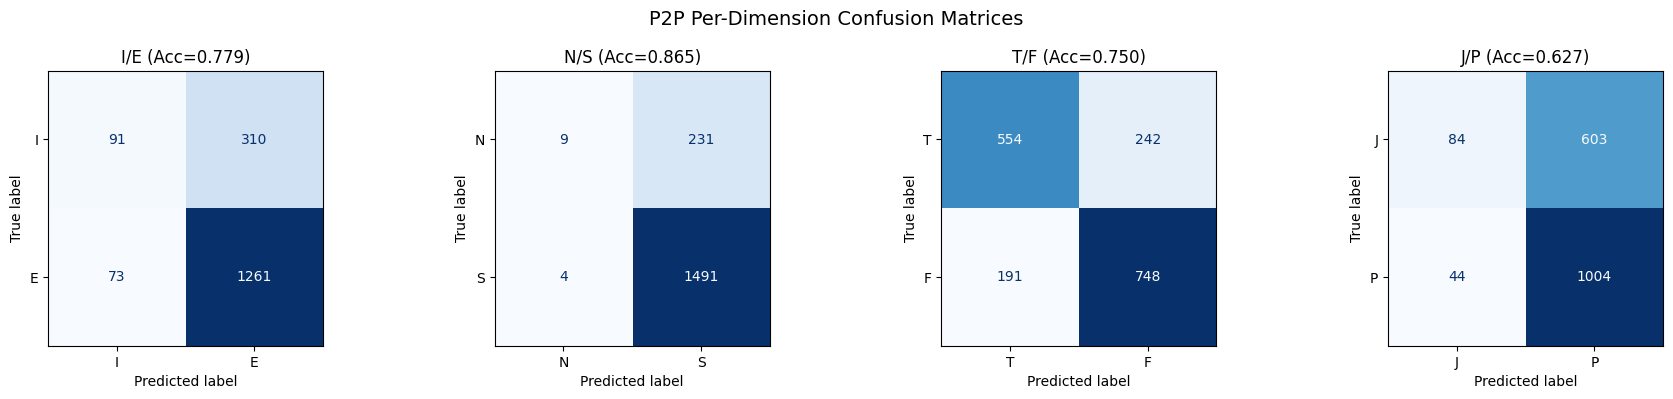

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, tc, pc) in zip(axes, dims):
    cm = confusion_matrix(valid[tc], valid[pc])
    ConfusionMatrixDisplay(cm, display_labels=name.split('/')).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} (Acc={results[name]["acc"]:.3f})')
plt.suptitle('P2P Per-Dimension Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'confusion_matrices.png', dpi=150)
plt.show()

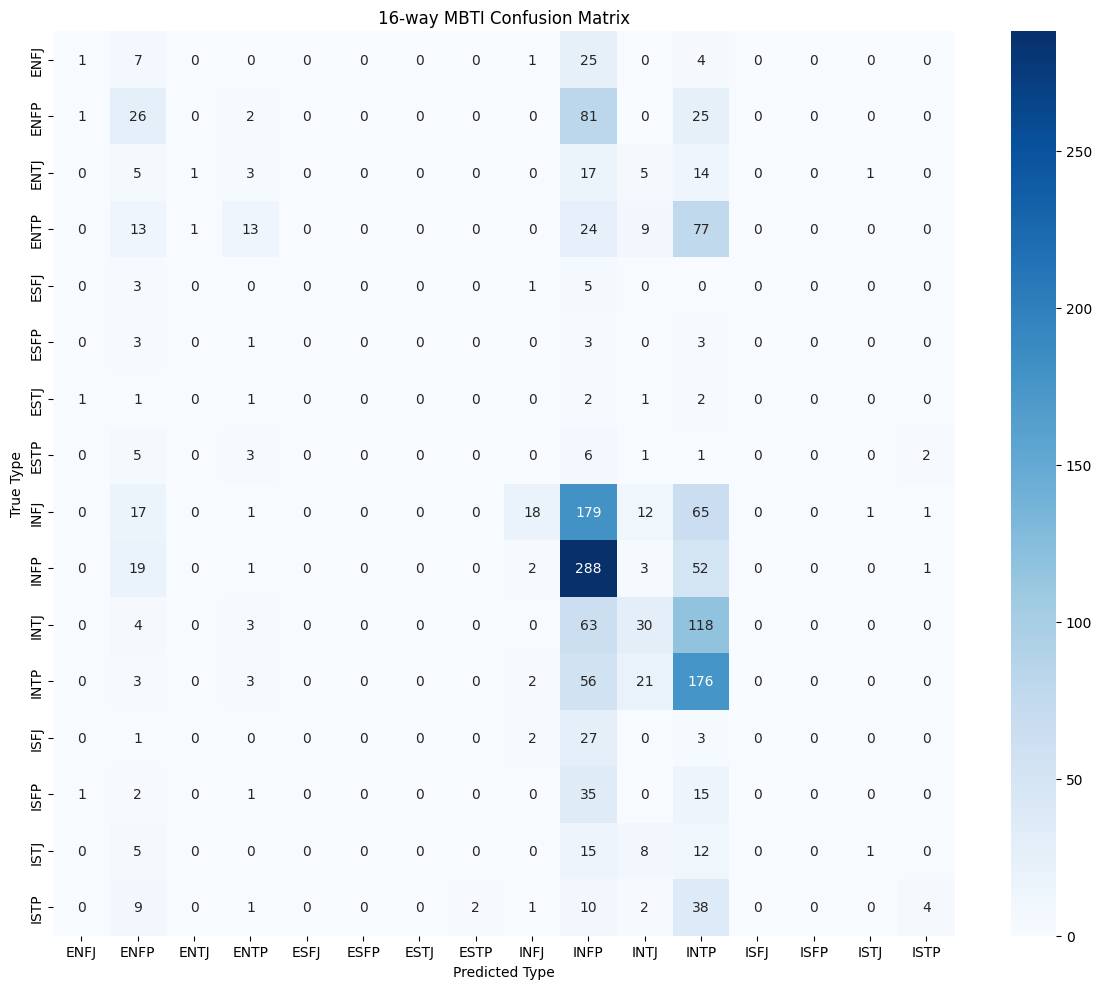

In [11]:
all_types = sorted(VALID_TYPES)
cm16 = confusion_matrix(valid['type'], valid['pred'], labels=all_types)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm16, annot=True, fmt='d', xticklabels=all_types, yticklabels=all_types,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Type')
ax.set_ylabel('True Type')
ax.set_title('16-way MBTI Confusion Matrix')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'confusion_matrix_16way.png', dpi=150)
plt.show()

---
## 7. Prediction Distribution Analysis

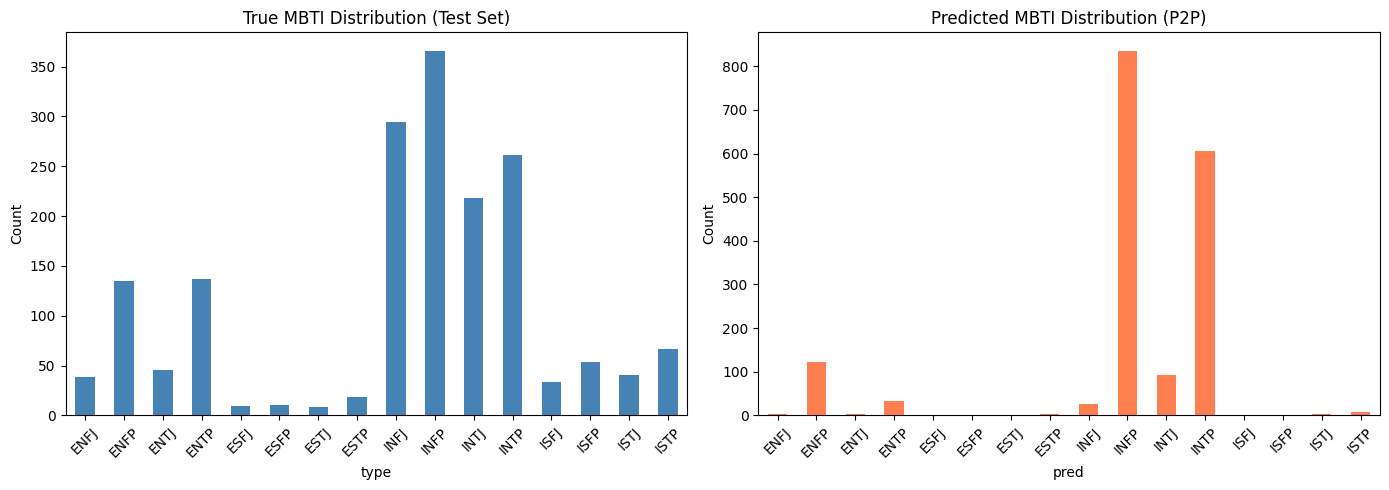

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid['type'].value_counts().reindex(all_types, fill_value=0).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('True MBTI Distribution (Test Set)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

valid['pred'].value_counts().reindex(all_types, fill_value=0).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Predicted MBTI Distribution (P2P)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
print('16-way Classification Report:\n')
print(classification_report(valid['type'], valid['pred'], zero_division=0))

16-way Classification Report:

              precision    recall  f1-score   support

        ENFJ       0.25      0.03      0.05        38
        ENFP       0.21      0.19      0.20       135
        ENTJ       0.50      0.02      0.04        46
        ENTP       0.39      0.09      0.15       137
        ESFJ       0.00      0.00      0.00         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       0.00      0.00      0.00         8
        ESTP       0.00      0.00      0.00        18
        INFJ       0.67      0.06      0.11       294
        INFP       0.34      0.79      0.48       366
        INTJ       0.33      0.14      0.19       218
        INTP       0.29      0.67      0.41       261
        ISFJ       0.00      0.00      0.00        33
        ISFP       0.00      0.00      0.00        54
        ISTJ       0.33      0.02      0.05        41
        ISTP       0.50      0.06      0.11        67

    accuracy                           0.32      

---

### References

Ma, T., Feng, K., Rong, Y., & Zhao, K. (2025). From Post To Personality: Harnessing LLMs for MBTI Prediction in Social Media. In *Proceedings of CIKM '25*. ACM.